Import the library.

In [3]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

Read the dataset.

In [4]:
df = pd.read_csv('Datasets/titanic_dataset.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


Find the missing/null values.

In [5]:
df['Age'].fillna(df['Age'].mean(),inplace=True)
df.isnull().sum()


/tmp/ipykernel_102780/396533459.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


Survived    0
Age         0
Fare        0
dtype: int64

Split data into train and test.

In [6]:
x = df.iloc[:,1:3].values
y = df.iloc[:,0].values

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

Plot the histogram and correspong QQ plot to find whether the data is normally distributed or not.

Text(0.5, 1.0, 'Age QQ Plot')

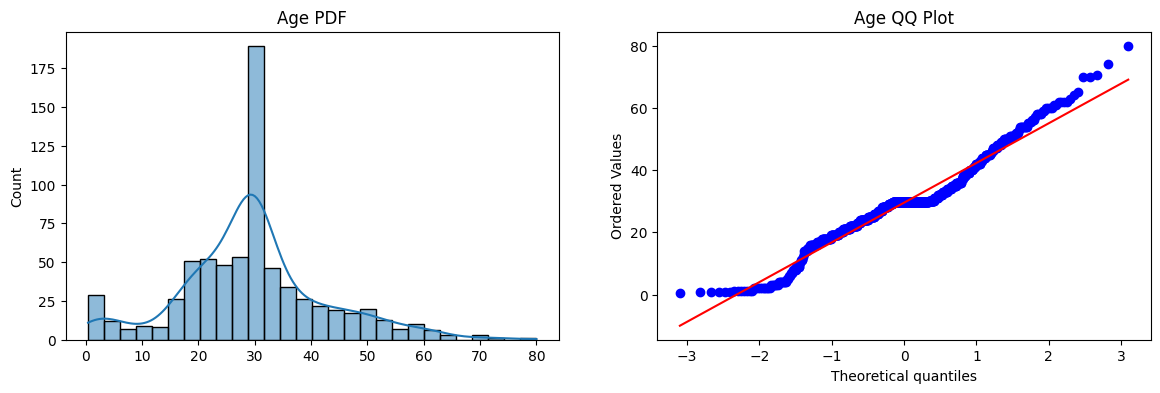

In [8]:
plt.figure(figsize=(14,4))
plt.subplot(121) # Same as plt.subplot(1,2,1) (nrow, ncols, index)
sns.histplot(x_train[:,0], kde=True)  # Using x_train[:,0] to access the Age column
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train[:,0], dist="norm", plot=plt)
plt.title('Age QQ Plot')


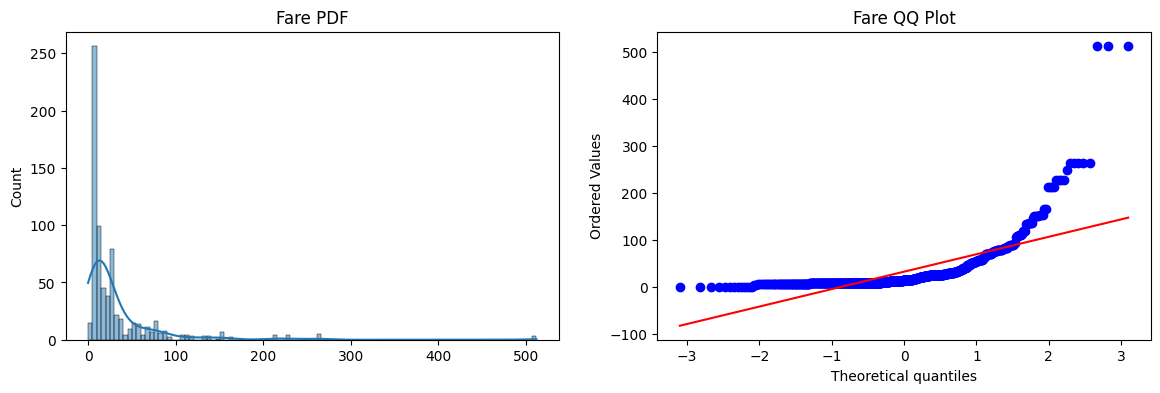

In [9]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(x_train[:,1], kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(x_train[:,1], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

Train the model by Logestic Regression and Decision Tree Clasifier and compare the accuracy scores.

In [10]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [11]:
clf1.fit(x_train, y_train)
clf2.fit(x_train, y_train)

y_pred1 = clf1.predict(x_test)
y_pred2 = clf2.predict(x_test)

print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred1))
print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred2))

Logistic Regression Accuracy: 0.6480446927374302
Decision Tree Accuracy: 0.664804469273743


Function Transform, by using log1p or log(1+x).

In [12]:
trf1 = FunctionTransformer(np.log1p, np.expm1)
x_train_trf1 = trf1.fit_transform(x_train)
x_test_trf1 = trf1.transform(x_test)

Training the model by transformed data.

In [13]:
clf1.fit(x_train_trf1, y_train)
clf2.fit(x_train_trf1, y_train)

y_pred1 = clf1.predict(x_test_trf1)
y_pred2 = clf2.predict(x_test_trf1)

print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred1))
print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred2))

Logistic Regression Accuracy: 0.6815642458100558
Decision Tree Accuracy: 0.6927374301675978


Training the data on whole x and getting cross validation score.

In [14]:
x_trf1 = trf1.fit_transform(x)

clf1.fit(x_trf1, y)
clf2.fit(x_trf1, y)

print("LogisticRegression Accuracy:", np.mean(cross_val_score(clf1, x_trf1, y, scoring='accuracy', cv=10)))
print("DecisionTree Accuracy:", np.mean(cross_val_score(clf2, x_trf1, y, scoring='accuracy', cv=10)))

LogisticRegression Accuracy: 0.678027465667915
DecisionTree Accuracy: 0.655505617977528


Plotting the graphs and QQ plots.

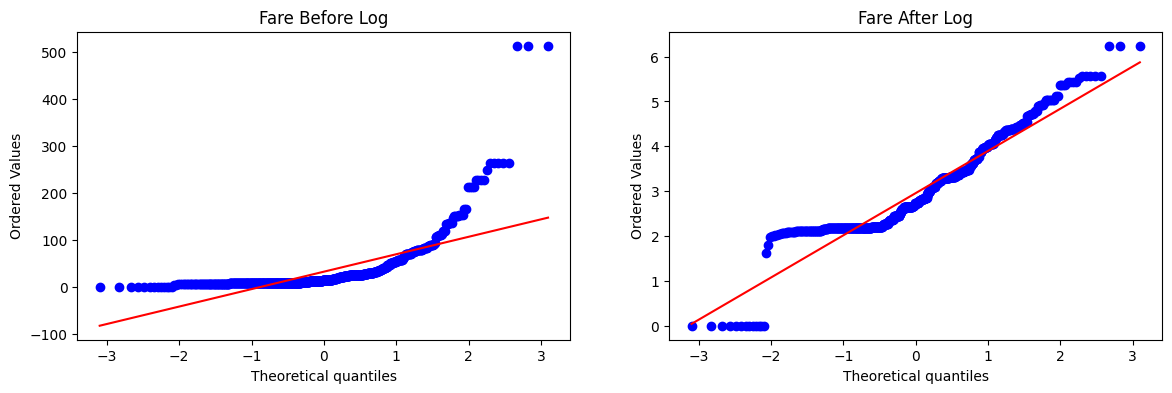

In [15]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train[:, 1], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(x_train_trf1[: , 1], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

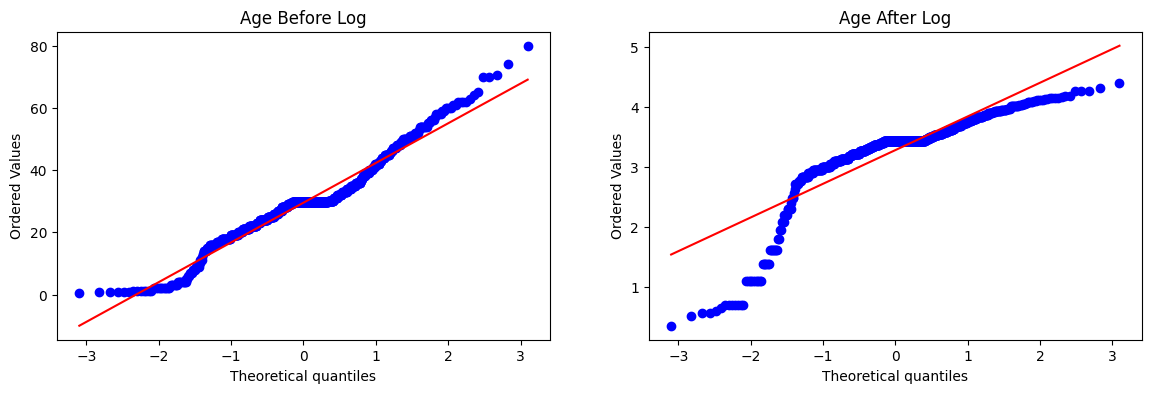

In [16]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train[:, 0], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(x_train_trf1[:, 0], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

Column tranformer [log(1+x)] on perticular column.

In [17]:
trf2 = ColumnTransformer(transformers=[('log', FunctionTransformer(np.log1p), [0])], remainder='passthrough')

x_train_trf2 = trf2.fit_transform(x_train)
x_test_trf2 = trf2.transform(x_test)

Find the accuracy score and cross validation score.

In [18]:
clf1.fit(x_train_trf2, y_train)
clf2.fit(x_train_trf2, y_train) 

y_pred1 = clf1.predict(x_test_trf2)
y_pred2 = clf2.predict(x_test_trf2)

print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred1))
print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred2))

Logistic Regression Accuracy: 0.6480446927374302
Decision Tree Accuracy: 0.6703910614525139


In [19]:
x_trf2 = trf2.fit_transform(x)

clf1.fit(x_trf2, y)
clf2.fit(x_trf2, y)

print("LogisticRegression Accuracy:", np.mean(cross_val_score(clf1, x_trf2, y, scoring='accuracy', cv=10)))
print("DecisionTree Accuracy:", np.mean(cross_val_score(clf2, x_trf2, y, scoring='accuracy', cv=10)))

LogisticRegression Accuracy: 0.6712484394506867
DecisionTree Accuracy: 0.6577153558052435


A function defined which train the data by doing specific input transform and printing the accuracy score and plot the graph and QQ plot.

In [20]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Some example with different function inputs.

Accuracy 0.6431335830212235


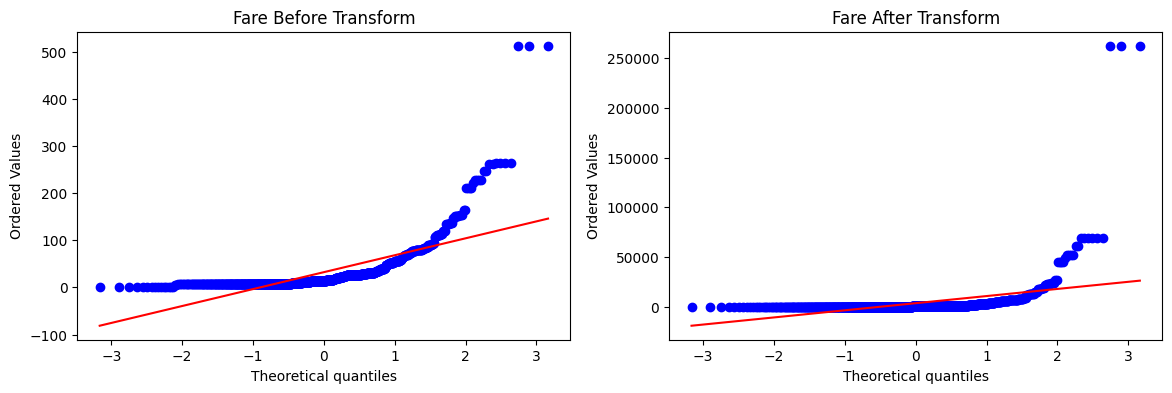

In [21]:
apply_transform(lambda x: x**2)

Accuracy 0.6611485642946316


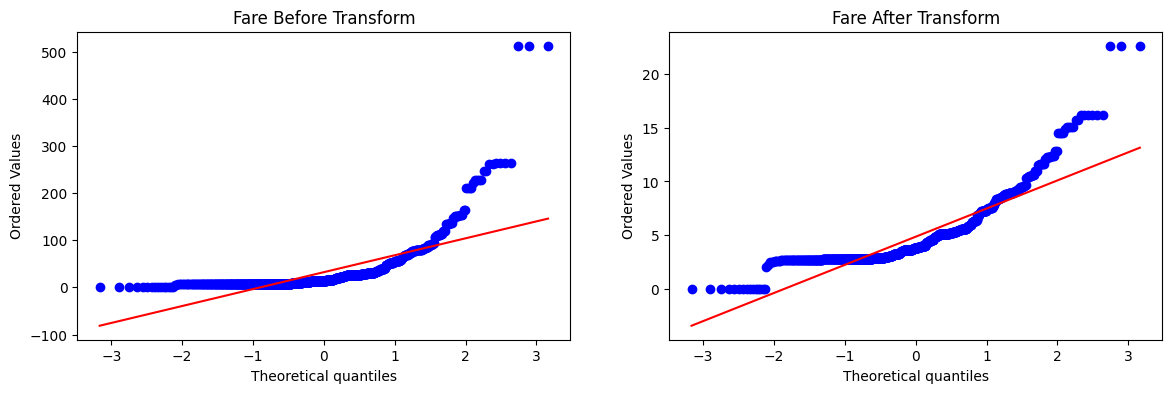

In [22]:
apply_transform(lambda x: np.sqrt(x))

Accuracy 0.61729088639201


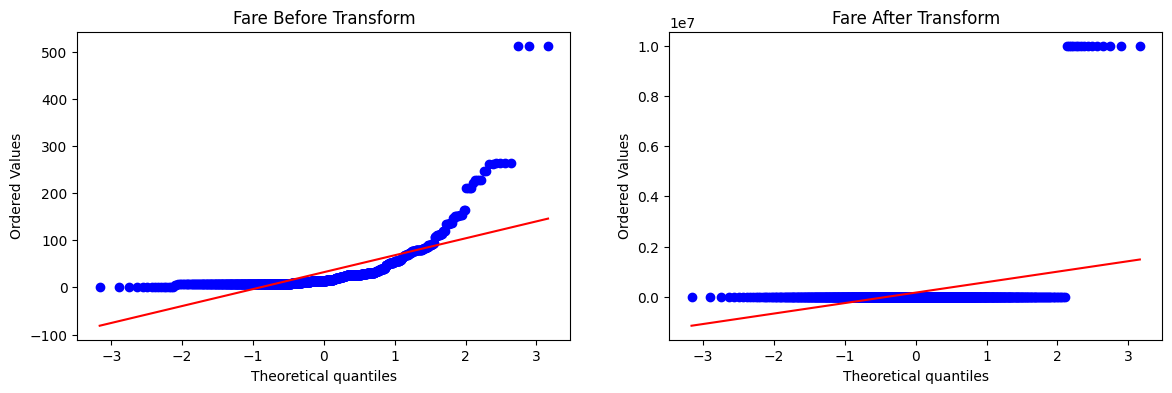

In [23]:
apply_transform(lambda x : 1/(x+0.0000001))

Accuracy 0.6195131086142323


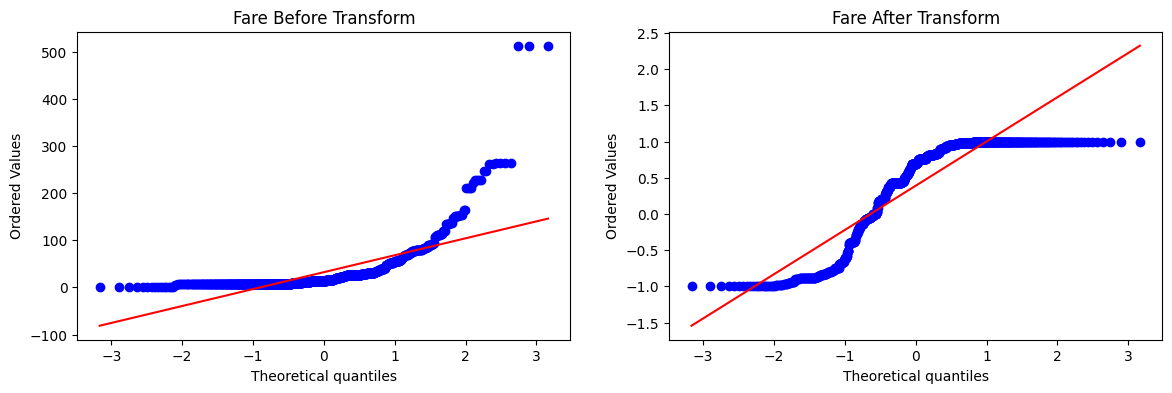

In [24]:
apply_transform(np.sin)